In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using ITensors
using ITensorMPS
using Plots

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


Valores singulares significativos detectados: 16
Usando un rango de K = 12

--- VERIFICACIÓN NUMÉRICA ---
Error absoluto máximo en todo el dominio: 4.8105842864742954e-8

--- Coeficientes Complejos ---
Término 1 -> w: 0.0 - 0.0im | s: -1.936 + 13.493im
Término 2 -> w: 0.0 + 0.0im | s: -1.936 - 13.493im
Término 3 -> w: 0.0 + 0.0im | s: -1.309 + 10.167im
Término 4 -> w: 0.0 - 0.0im | s: -1.309 - 10.167im
Término 5 -> w: 5.902 + 3.825im | s: 0.788 + 0.853im
Término 6 -> w: 5.902 - 3.825im | s: 0.788 - 0.853im
Término 7 -> w: -0.002 + 0.003im | s: -0.71 + 7.44im
Término 8 -> w: -0.002 - 0.003im | s: -0.71 - 7.44im
Término 9 -> w: -0.943 + 0.499im | s: 0.33 + 2.897im
Término 10 -> w: -0.943 - 0.499im | s: 0.33 - 2.897im
Término 11 -> w: 0.043 - 0.078im | s: -0.168 + 5.049im
Término 12 -> w: 0.043 + 0.078im | s: -0.168 - 5.049im


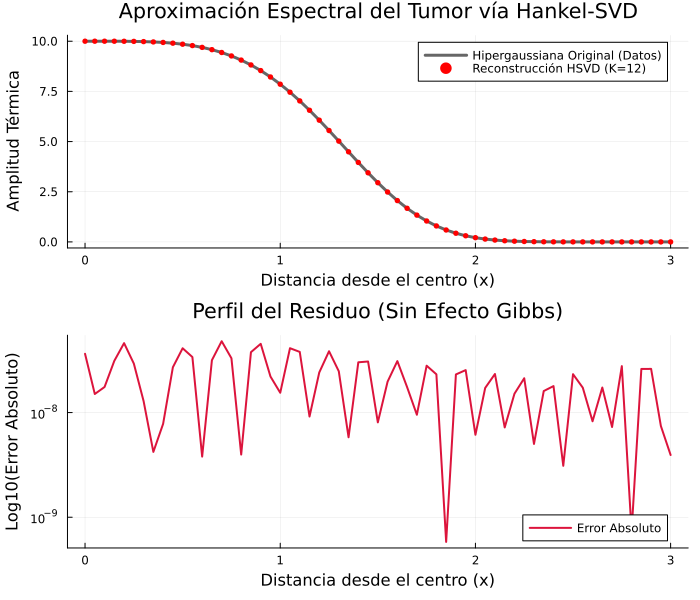

In [19]:
using LinearAlgebra
using Plots
using Printf
"""
    coeficientes_hsvd(y_datos, dx, K; cutoff=1e-12)

Calcula de forma algebraica pura los pesos (w) y exponentes (s) para aproximar
un vector de datos como una suma de exponenciales: y(x) ≈ ∑ w_k * exp(-s_k * x).
"""
function coeficientes_hsvd_complejos(y_datos, dx, K; cutoff=1e-13)
    N = length(y_datos)
    L = div(N, 2)
    M = N - L + 1

    H = [y_datos[i + j - 1] for i in 1:L, j in 1:M]

    U, S, V = svd(H)

    rango_efectivo = count(s -> s > (S[1] * cutoff), S)
    K_real = min(K, rango_efectivo)
    
    println("Valores singulares significativos detectados: ", rango_efectivo)
    println("Usando un rango de K = ", K_real)

    U_k = U[:, 1:K_real]

    U_arriba = U_k[1:(end-1), :]
    U_abajo  = U_k[2:end, :]
    
    Z = pinv(U_arriba) * U_abajo
    q_k = eigvals(Z)

    # --- CORRECCIÓN CLAVE: PRESERVAR EL PLANO COMPLEJO ---
    # Mantenemos s_k como ComplexF64 para no destruir las frecuencias oscilatorias
    s_k = -log.(complex.(q_k)) ./ dx
    
    # 4. Encontrar los pesos (w_k) usando aritmética compleja
    A = zeros(ComplexF64, N, K_real)
    for i in 1:N
        x_i = (i - 1) * dx
        for j in 1:K_real
            A[i, j] = exp(-s_k[j] * x_i)
        end
    end

    # Pesos complejos
    w_k = A \ complex.(y_datos)

    return w_k, s_k
end
# =========================================================================
# EJEMPLO DE USO: Aplicado a la mitad derecha de una Hipergaussiana (m=2)
# =========================================================================

# Configuración del dominio de prueba (mitad derecha del tumor desde el centro x=0)
dx = 0.05
x_prueba = 0.0:dx:3.0
Q_tumor = 10.0
σ = 1.2
m = 2

# Generamos los datos limpios de la hipergaussiana
y_tumor = [Q_tumor * exp(-(x^(2*m)) / (2 * σ^(2*m))) for x in x_prueba]

# =========================================================================
# 1. RECONSTRUCCIÓN CON LOS COEFICIENTES HALLADOS
# =========================================================================
# 1. Calculamos los coeficientes complejos con K=6
w, s = coeficientes_hsvd_complejos(y_tumor, dx, 12)

# 2. Reconstruimos tomando la componente real del resultado
y_reconstruida = [real(sum(w[k] * exp(-s[k] * x) for k in 1:length(w))) for x in x_prueba]

error_absoluto = abs.(y_tumor .- y_reconstruida)
max_error = maximum(error_absoluto)

println("\n--- VERIFICACIÓN NUMÉRICA ---")
println("Error absoluto máximo en todo el dominio: ", max_error)

# --- Mostrar Coeficientes ---
println("\n--- Coeficientes Complejos ---")
for i in 1:length(w)
    println("Término $i -> w: ", round(w[i], digits=3), " | s: ", round(s[i], digits=3))
end

# =========================================================================
# 2. RENDERIZADO DE LA GRÁFICA DE VERIFICACIÓN
# =========================================================================

# Gráfica Principal: Comparativa del perfil del tumor
plt_perfil = plot(x_prueba, y_tumor, 
    label="Hipergaussiana Original (Datos)", 
    linewidth=3, 
    color=:black, 
    alpha=0.6)

scatter!(plt_perfil, x_prueba, y_reconstruida, 
    label="Reconstrucción HSVD (K=$(length(w)))", 
    markersize=3, 
    color=:red, 
    marker=:circle,
    markerstrokewidth=0)

plot!(plt_perfil, 
    title="Aproximación Espectral del Tumor vía Hankel-SVD",
    xlabel="Distancia desde el centro (x)",
    ylabel="Amplitud Térmica",
    legend=:topright,
    grid=true)

# Gráfica Secundaria: El perfil del error (escala logarítmica para ver la precisión)
plt_error = plot(x_prueba, error_absoluto, 
    label="Error Absoluto", 
    linewidth=2, 
    color=:crimson,
    yscale=:log10) # Escala logarítmica para apreciar precisiones extremas

plot!(plt_error, 
    title="Perfil del Residuo (Sin Efecto Gibbs)",
    xlabel="Distancia desde el centro (x)",
    ylabel="Log10(Error Absoluto)",
    legend=:bottomright,
    grid=true)

# Combinamos ambas gráficas en un layout vertical espectacular
plt_final = plot(plt_perfil, plt_error, layout=(2,1), size=(700,600))

display(plt_final)